# Credit Scorecard — Exploratory Data Analysis

**Purpose:** understand the raw credit application data before WoE binning and scorecard development.
This notebook is exploration only — findings get ported into `src/train_credit_scorecard.py`.

**Dataset expected columns:** an ID column (`applicant_id`), numeric/categorical features,
and a binary target column (default name: `default`, 1 = defaulted, 0 = good).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Load the data

In [2]:
DATA_PATH = "../data/applications_synthetic.csv"  # <- point this at your real dataset

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()


Shape: (8000, 8)


,applicant_id,age,income,debt_ratio,employment_length,num_credit_lines,late_payments_2y,default
0,APP0,30,4755.18,0.328,14,7,0,0
1,APP1,47,6294.47,0.035,14,11,0,0
2,APP2,52,12506.70,0.229,28,6,0,0
3,APP3,42,2824.44,0.425,11,2,0,1
4,APP4,33,5885.05,0.202,19,14,0,0


## 2. Default rate — class balance check

Credit default datasets are usually less extreme than fraud (often 5-25% default rate),
but still imbalanced enough that accuracy alone is misleading. This is also the number
used as the prior when interpreting Weight of Evidence later.

Default rate: 21.18%
Default count: 1,694 / 8,000 applicants


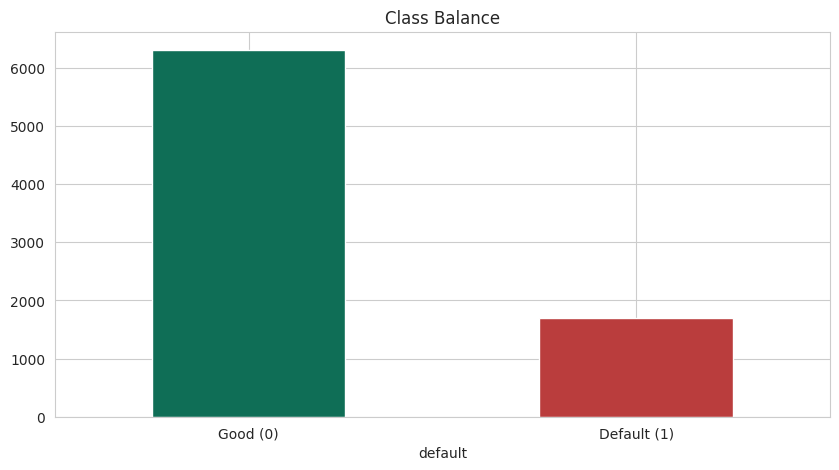

In [3]:
default_rate = df["default"].mean()
print(f"Default rate: {default_rate*100:.2f}%")
print(f"Default count: {df['default'].sum():,} / {len(df):,} applicants")

ax = df["default"].value_counts().plot(kind="bar", color=["#0F6E56", "#BA3D3D"])
ax.set_xticklabels(["Good (0)", "Default (1)"], rotation=0)
ax.set_title("Class Balance")
plt.show()


## 3. Missing values and data types

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print("Columns with missing values:" if len(missing_df) else "No missing values found.")
missing_df


No missing values found.


,missing_count,missing_pct


In [5]:
df.dtypes


applicant_id             str
age                    int64
income               float64
debt_ratio           float64
employment_length      int64
num_credit_lines       int64
late_payments_2y       int64
default                int64
dtype: object

## 4. Feature distributions split by default status

For each numeric feature, comparing the distribution for good vs. defaulted applicants
gives an early read on which features will likely have high Information Value later.

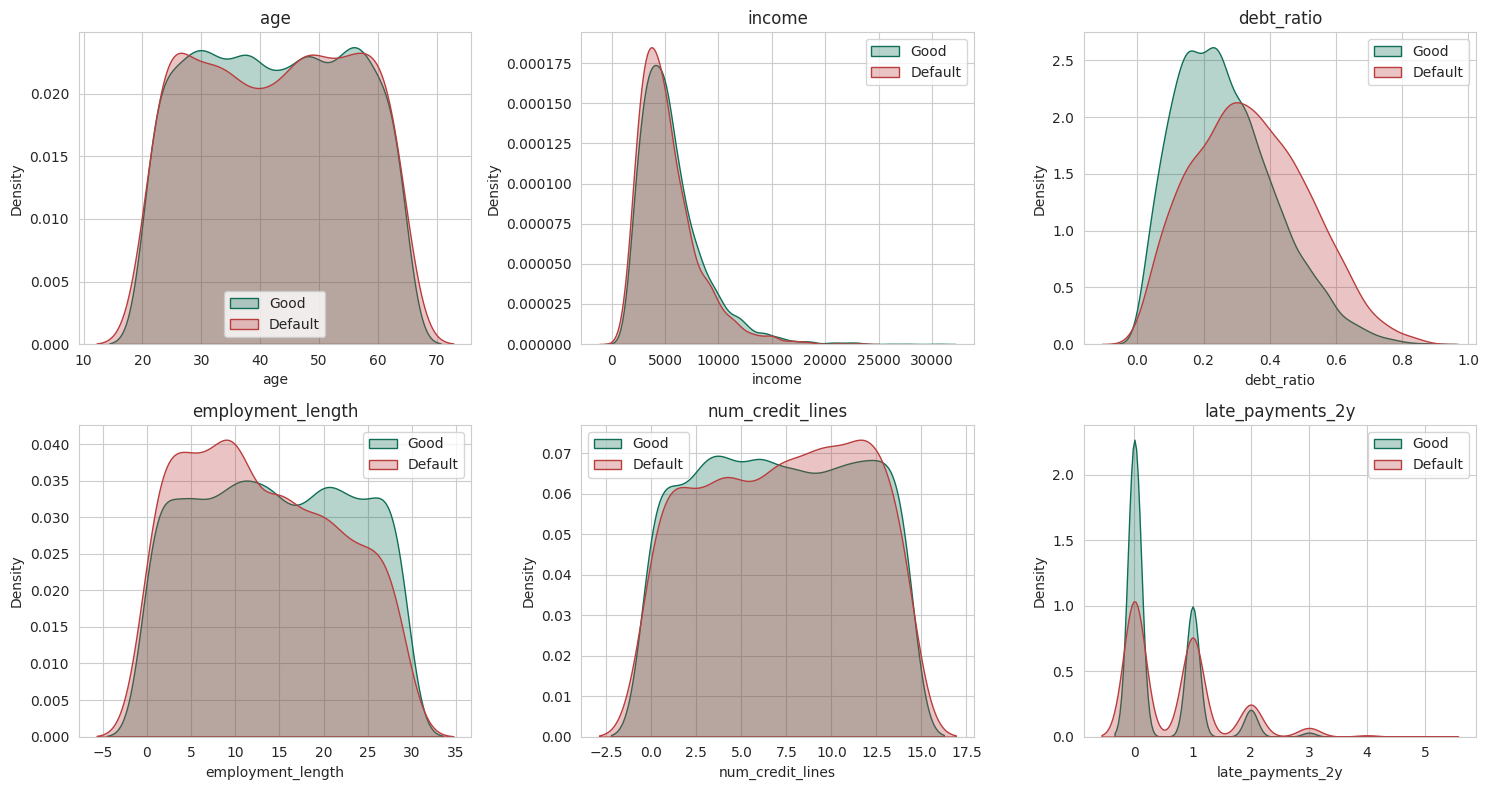

In [6]:
id_cols = [c for c in ["applicant_id", "id", "SK_ID_CURR"] if c in df.columns]
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in id_cols + ["default"]]

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, col in enumerate(numeric_cols):
    sns.kdeplot(df[df.default == 0][col], label="Good", color="#0F6E56", ax=axes[i], fill=True, alpha=0.3)
    sns.kdeplot(df[df.default == 1][col], label="Default", color="#BA3D3D", ax=axes[i], fill=True, alpha=0.3)
    axes[i].set_title(col)
    axes[i].legend()

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 5. Quick-and-dirty Information Value preview

A simplified IV calculation using manual quantile binning — just to get an early read
before running the full `optbinning` optimal binning in the training script. This is
NOT the same algorithm as the production script; treat it as a rough signal only.

In [7]:
def quick_iv(df, feature, target, bins=10):
    try:
        binned = pd.qcut(df[feature], bins, duplicates="drop")
    except ValueError:
        binned = pd.cut(df[feature], bins)

    grouped = df.groupby(binned, observed=True)[target].agg(["count", "sum"])
    grouped.columns = ["total", "bad"]
    grouped["good"] = grouped["total"] - grouped["bad"]

    total_good = grouped["good"].sum()
    total_bad = grouped["bad"].sum()

    grouped["good_pct"] = grouped["good"] / total_good
    grouped["bad_pct"] = grouped["bad"] / total_bad
    grouped["good_pct"] = grouped["good_pct"].replace(0, 0.0001)
    grouped["bad_pct"] = grouped["bad_pct"].replace(0, 0.0001)

    grouped["woe"] = np.log(grouped["good_pct"] / grouped["bad_pct"])
    grouped["iv_contribution"] = (grouped["good_pct"] - grouped["bad_pct"]) * grouped["woe"]

    return grouped["iv_contribution"].sum()


iv_preview = []
for col in numeric_cols:
    try:
        iv = quick_iv(df, col, "default")
        iv_preview.append({"feature": col, "quick_iv": round(iv, 4)})
    except Exception as e:
        iv_preview.append({"feature": col, "quick_iv": None})

iv_preview_df = pd.DataFrame(iv_preview).sort_values("quick_iv", ascending=False)
iv_preview_df


,feature,quick_iv
2,debt_ratio,0.2248
5,late_payments_2y,0.0748
3,employment_length,0.0383
1,income,0.0218
4,num_credit_lines,0.0063
0,age,0.0036


## 6. Correlation matrix

Checking for multicollinearity — highly correlated features can make scorecard points
harder to interpret individually, even though the model performance won't necessarily suffer.

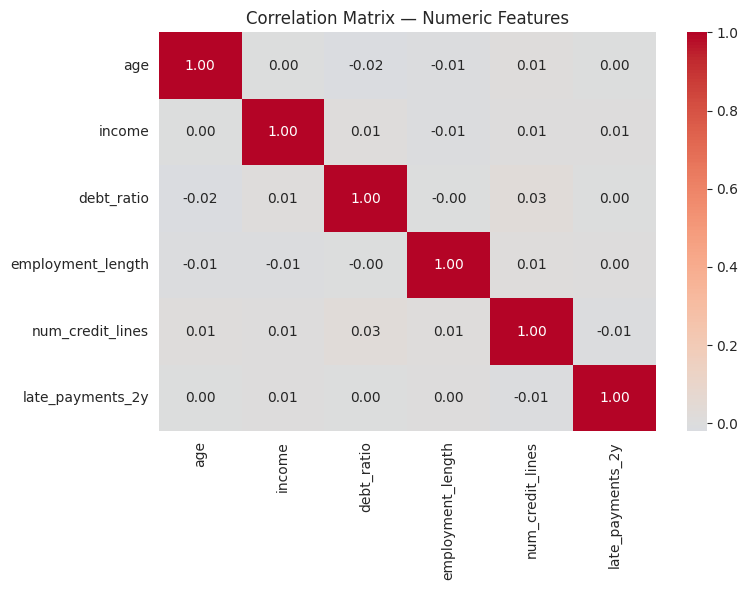

In [8]:
plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


## 7. Outlier check\n\nExtreme outliers can distort WoE binning edges. Quick boxplot pass to flag anything suspicious.

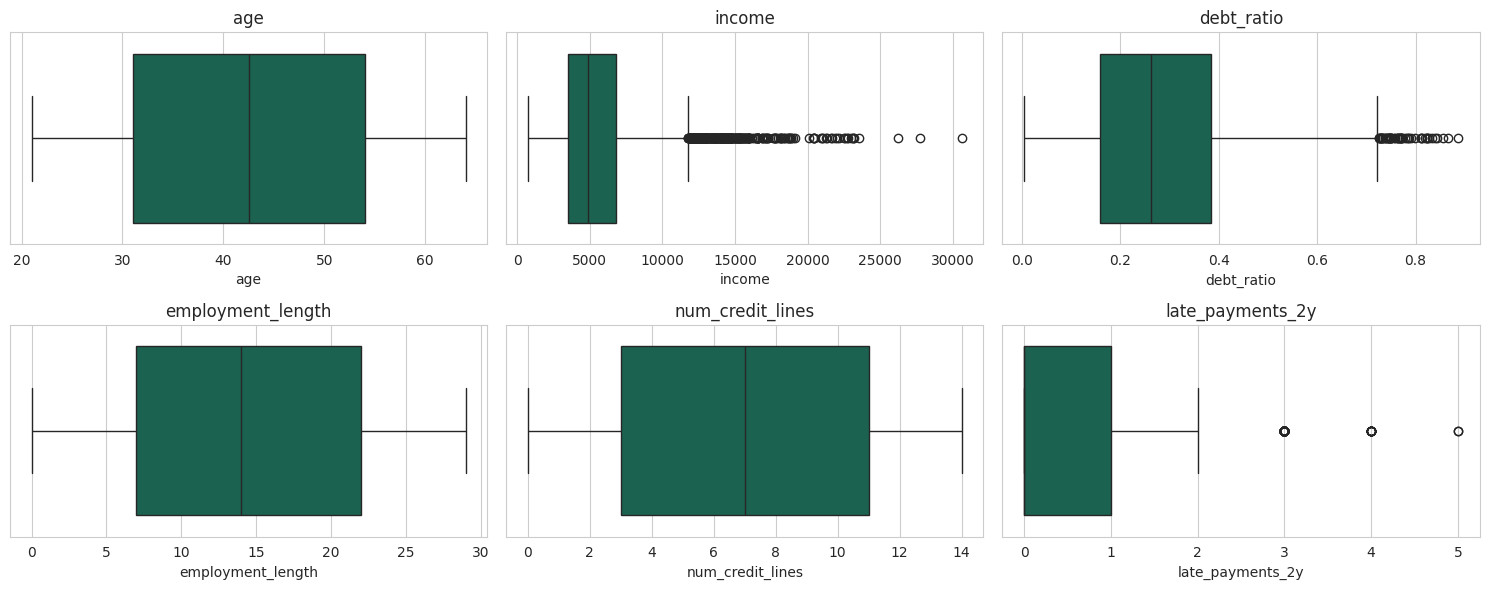

In [9]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color="#0F6E56")
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 8. Findings summary

Fill this in after reviewing the plots above, e.g.:

- Default rate: ~X% — informs base odds assumption used in the scorecard's PDO scaling.
- [Feature] shows the cleanest separation between good/default and the highest quick-IV — likely a strong scorecard feature.
- [Feature] shows almost no separation — likely to be dropped at the IV-filtering step (threshold 0.02).
- [Any outliers found] — optbinning's optimal binning should absorb most of these automatically via bin edges, but worth double-checking the final bin table.
- [Any multicollinearity found] — scorecard points may double-count related risk; consider dropping one of a highly correlated pair if points seem hard to justify to stakeholders.

**Next step:** run `src/train_credit_scorecard.py` on the full dataset and compare its IV table against the quick preview above — the optimal binning version should show higher real IV per feature than this notebook's quantile approximation.